# Install dependencies 
in bash terminal, do:

python -m pip install pandas seaborn matplotlib scikit-learn pydotplus ipykernel

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import json
import pydotplus

from pathlib import Path
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn import tree
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GroupShuffleSplit
dataset = pd.read_csv("../dataset/PCA_datasets/full_v4_pca_yeo-johnson_2026-10-01_17-12-09.csv")
from IPython.display import Image

In [2]:
df_pca = pd.read_csv('../dataset/PCA_datasets/full_v4_pca_yeo-johnson_2026-10-01_17-12-09.csv')
df_pca.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC81,PC82,PC83,PC84,PC85,PC86,PC87,PC88,subject,Activity
0,-11.552402,1.723772,2.346996,8.533060,-0.224374,-0.067294,3.819454,0.662042,0.824410,-0.386227,...,0.292498,-0.658183,-0.735144,-0.213249,-0.982556,0.310451,0.792838,0.842045,1,STANDING
1,-2.264507,-3.108915,-1.432700,1.125572,-1.048343,-1.499094,3.517914,-0.030733,-0.091470,-2.269275,...,-0.255876,0.840966,-0.407073,-0.332361,0.441930,-0.713658,0.736757,-1.994001,3,STANDING
2,-9.460683,-0.892321,-2.123310,4.550429,0.803871,-0.732076,0.058888,0.781478,-0.020931,-1.728804,...,-0.736957,0.012483,0.212978,-0.254274,0.252554,-0.334354,0.102270,-0.052334,1,STANDING
3,-7.218036,-4.732282,-0.502230,3.718350,0.799629,-1.428685,2.465013,2.737118,-0.436518,2.877746,...,0.540501,0.424261,0.316522,0.264829,-0.254833,-1.643265,-0.433616,0.088936,3,STANDING
4,-9.059873,0.208189,-2.464919,4.580265,-0.269384,-0.608020,0.393577,1.354276,-0.541040,-0.308421,...,0.575412,0.008193,0.173754,0.133451,1.348293,-0.324317,0.221444,-0.397093,1,STANDING


In [3]:
from sklearn.preprocessing import LabelEncoder

X = df_pca.drop(columns=["Activity", "subject"])
y_text = df_pca["Activity"]
groups = df_pca["subject"]

le = LabelEncoder()
y = pd.Series(
    le.fit_transform(y_text),
    index=y_text.index,
    name="Activity"
)

print("Encoded mapping:")
for encoded_value, activity in enumerate(le.classes_):
    print(encoded_value, "=", activity)

Encoded mapping:
0 = LAYING
1 = SITTING
2 = STANDING
3 = WALKING
4 = WALKING_DOWNSTAIRS
5 = WALKING_UPSTAIRS


In [4]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=69)

# Get indices for train and test sets based on Subject groups
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
groups_train, groups_test = groups.iloc[train_idx], groups.iloc[test_idx]

train_subjects = sorted(groups_train.unique())
test_subjects = sorted(groups_test.unique())

print("Subjects in training data:")
print(train_subjects)

print("\nSubjects in test data:")
print(test_subjects)

print("\nNumber of training subjects:", len(train_subjects))
print("Number of test subjects:", len(test_subjects))

overlap = set(train_subjects) & set(test_subjects)
print("\nOverlapping subjects:", overlap)
print("Number of overlapping subjects:", len(overlap))

Subjects in training data:
[np.int64(1), np.int64(2), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(17), np.int64(18), np.int64(19), np.int64(21), np.int64(23), np.int64(24), np.int64(27), np.int64(28), np.int64(29), np.int64(30)]

Subjects in test data:
[np.int64(3), np.int64(9), np.int64(14), np.int64(15), np.int64(16), np.int64(20), np.int64(22), np.int64(25), np.int64(26)]

Number of training subjects: 21
Number of test subjects: 9

Overlapping subjects: set()
Number of overlapping subjects: 0


In [5]:
X = df_pca.drop(["Activity", "subject"], axis=1) # Predictors (69 components)
y = df_pca["Activity"]                        # Target variable
le = LabelEncoder()
y = le.fit_transform(y)
y = pd.DataFrame(y)
groups = df_pca["subject"]

In [6]:
model = DecisionTreeClassifier(criterion="entropy", random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Calculate metrics and the normalized matrix
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

labels = list(range(len(le.classes_)))
cm_percent = confusion_matrix(
    y_test, 
    y_pred, 
    labels=labels, 
    normalize="true"
)

Accuracy: 0.6905829596412556

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.82      0.82       594
           1       0.58      0.59      0.58       555
           2       0.72      0.72      0.72       581
           3       0.78      0.59      0.68       504
           4       0.56      0.61      0.58       414
           5       0.67      0.78      0.72       474

    accuracy                           0.69      3122
   macro avg       0.69      0.69      0.68      3122
weighted avg       0.70      0.69      0.69      3122



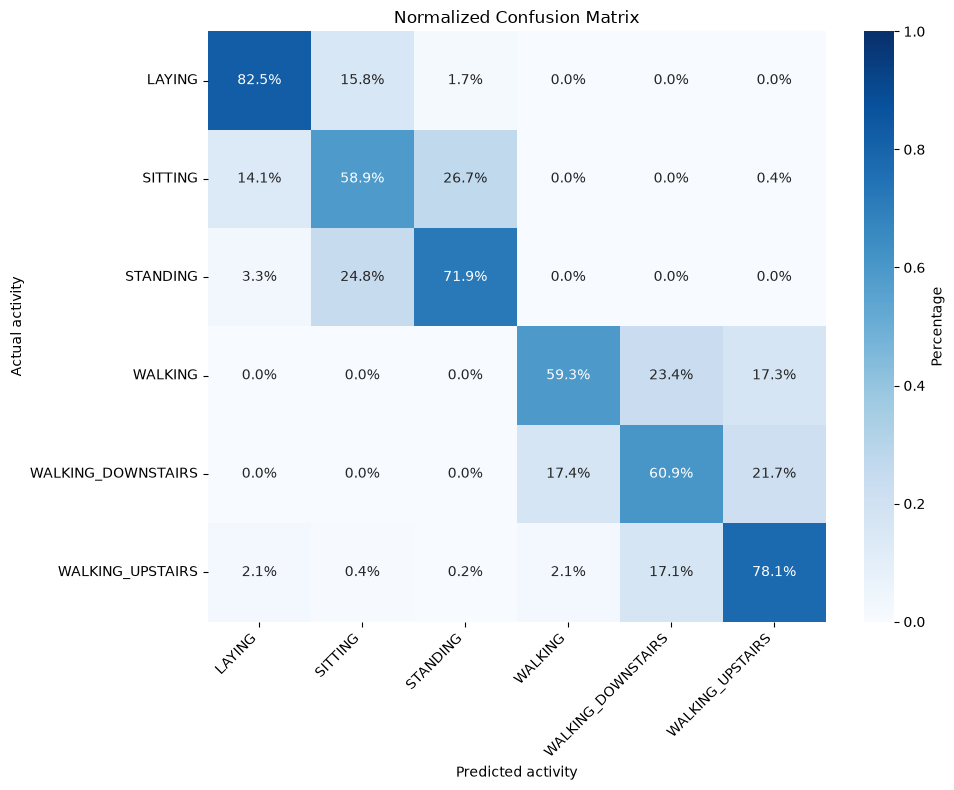

In [7]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    cm_percent,
    annot=True,
    fmt=".1%",
    cmap="Blues",
    vmin=0,
    vmax=1,
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cbar_kws={"label": "Percentage"}
)

plt.title("Normalized Confusion Matrix")
plt.xlabel("Predicted activity")
plt.ylabel("Actual activity")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [8]:
y_test_names = le.inverse_transform(y_test)
y_pred_names = le.inverse_transform(y_pred)

print(y_pred_names[:10])

['STANDING' 'STANDING' 'STANDING' 'STANDING' 'STANDING' 'STANDING'
 'STANDING' 'STANDING' 'STANDING' 'STANDING']


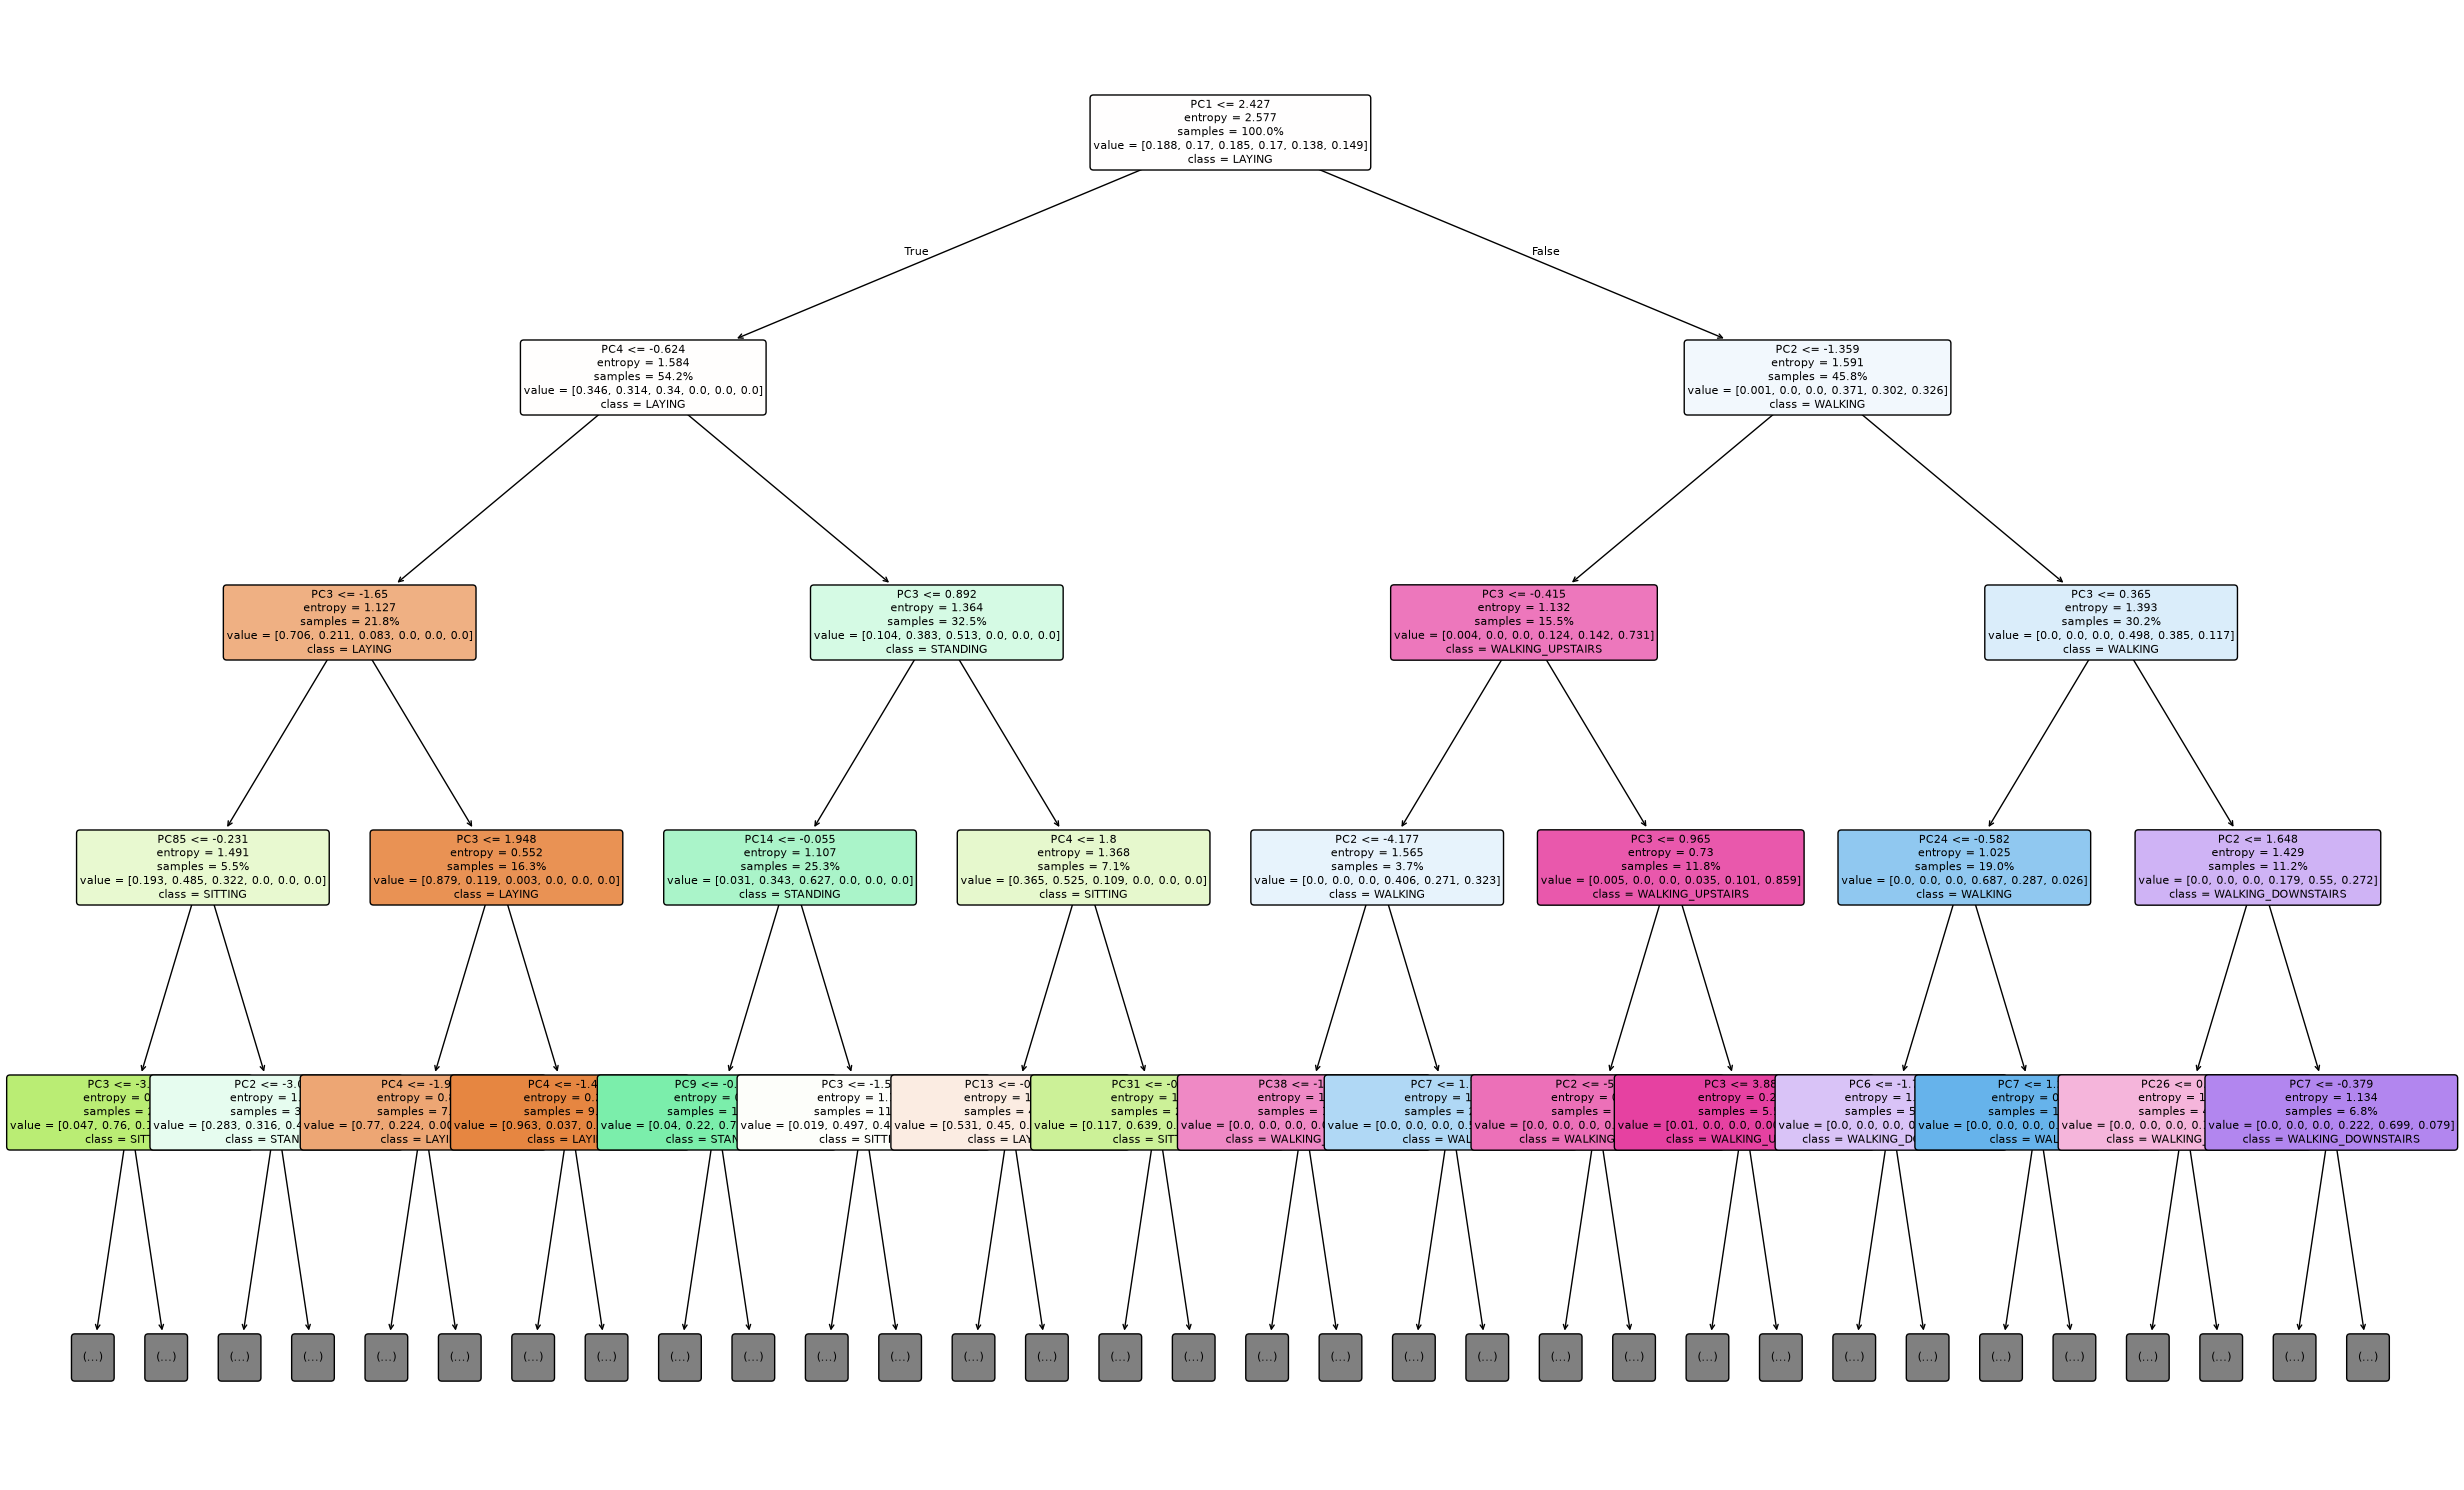

In [9]:
plt.figure(figsize=(25, 15))

tree.plot_tree(
    model,
    feature_names=X.columns.tolist(),
    class_names=le.classes_.astype(str).tolist(),
    filled=True,
    rounded=True,
    fontsize=8,
    proportion=True,
    max_depth=4  # Prevents rendering 69 PCA components into an illegible graph
)

plt.tight_layout()
plt.show()

In [10]:
# 1. Name the current model run
model_name = "cart_v3 Decision Tree"

# 2. Extract metrics
report = classification_report(y_test, y_pred, target_names=le.classes_, output_dict=True)
cm_normalized = confusion_matrix(
    y_test, 
    y_pred, 
    labels=list(range(len(le.classes_))), 
    normalize="true"
).round(4).tolist()

# 3. Assemble record
log_entry = {
    "timestamp": datetime.now().isoformat(),
    "model": model_name,
    "accuracy": float(accuracy_score(y_test, y_pred)),
    "macro_f1": float(report["macro avg"]["f1-score"]),
    "classes": le.classes_.tolist(),
    "confusion_matrix_percent": cm_normalized,
    "classification_report": report
}

# 4. Append one clean JSON line to file
log_file = Path("model_results.jsonl")
with open(log_file, "a", encoding="utf-8") as f:
    f.write(json.dumps(log_entry) + "\n")

print(f"Logged run for '{model_name}' to {log_file.resolve()}")

Logged run for 'cart_v3 Decision Tree' to C:\Users\adria\VSCode_Projects\machineLearning\HAML-ET\modelling\model_results.jsonl
